# Google Serper

#### ***Reference URL***

https://python.langchain.com/docs/integrations/tools/google_serper/

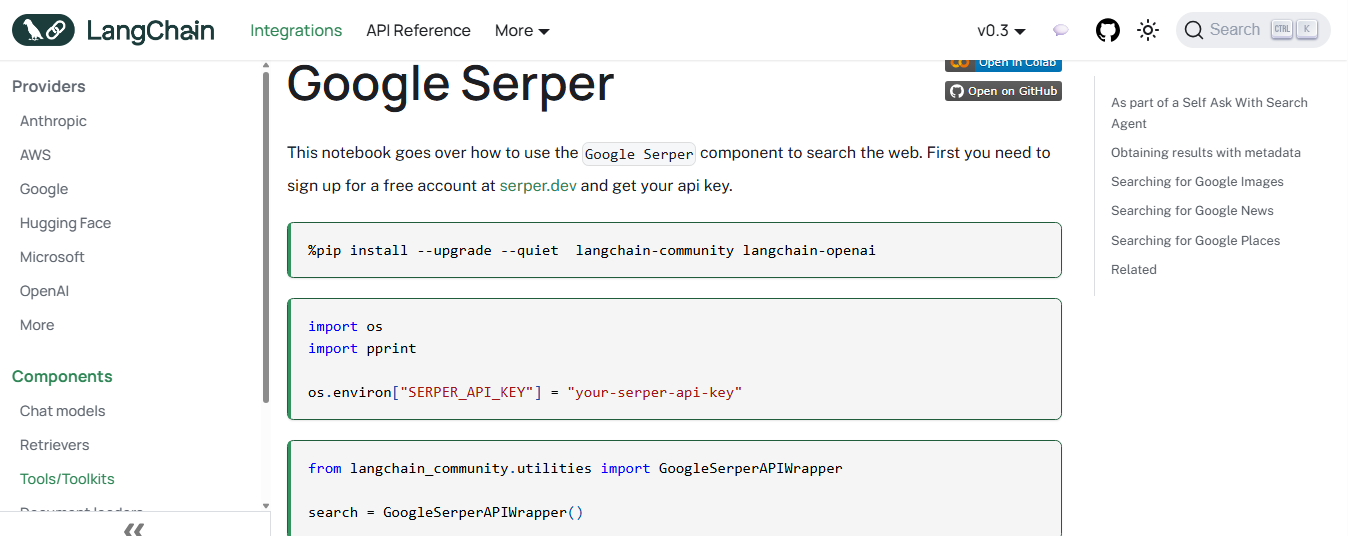

#### ***Reference URL***

https://serper.dev/

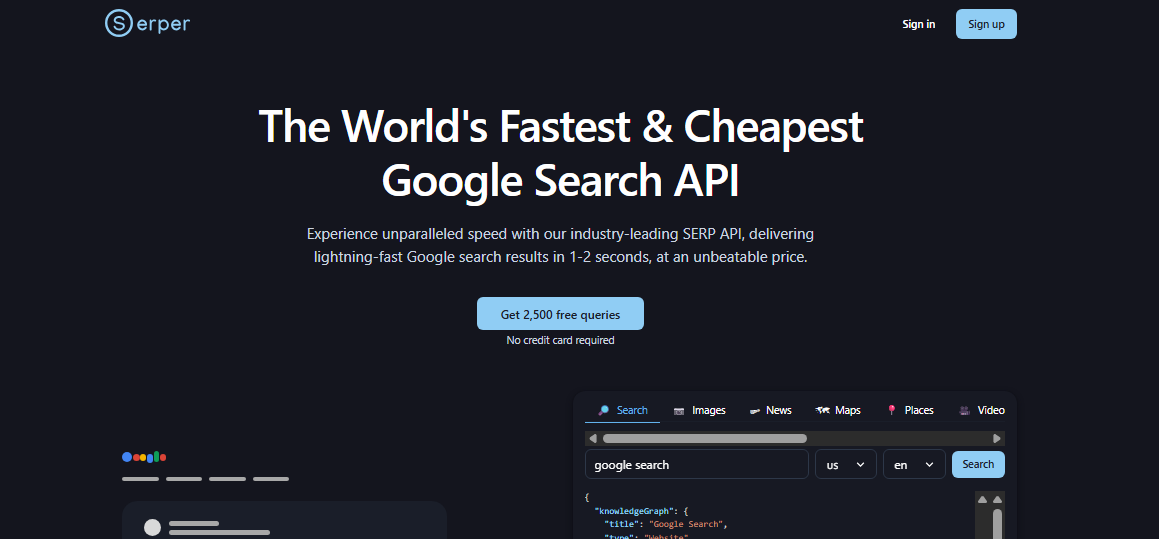

`Login to Serper and generate API Key.`

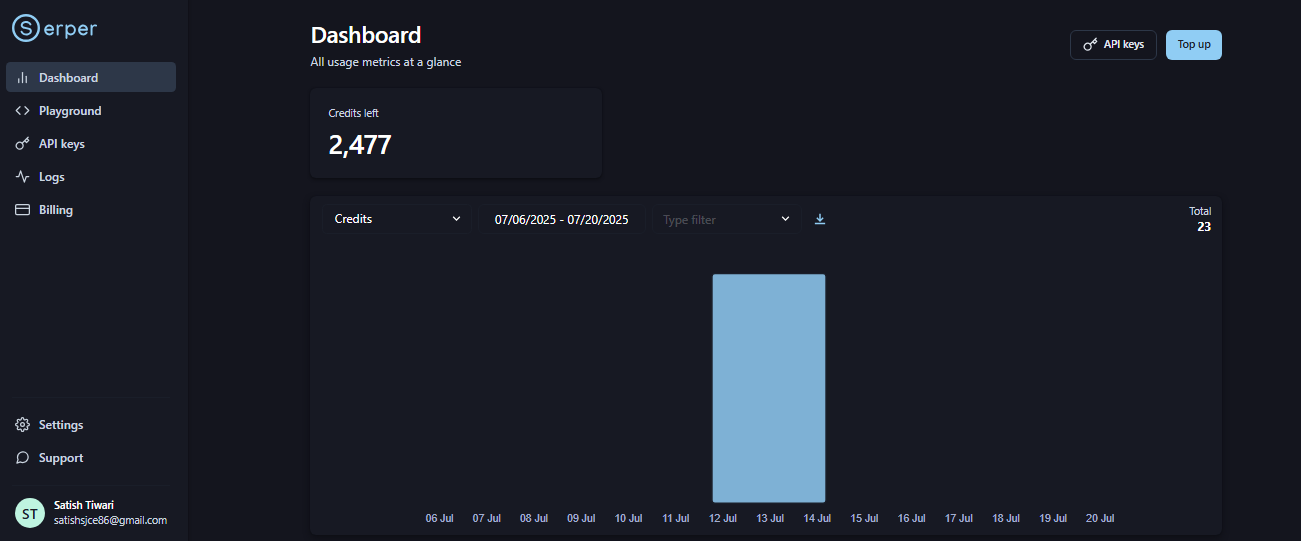

In [2]:
import asyncio, os
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.teams import SelectorGroupChat
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.conditions import TextMentionTermination
from dotenv import load_dotenv

In [3]:
# Load environment variables
load_dotenv()
serper_api_key=os.getenv("SERPER_API_KEY")
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("Please set the OPENAI_API_KEY environment variable.")

In [6]:
# Model client

model_client = OpenAIChatCompletionClient(model='gpt-4o', api_key=api_key)

In [15]:
# Planning Assistant Agent

planning_agent= AssistantAgent(
    name="PlanningAgent",
    description="An agent for planning tasks, this agent should be the first to engage when given a new task.",
    model_client=model_client,
    system_message="""
    You are a planning agent.
    Your job is to break down complex tasks into smaller, manageable subtasks.
    Your team members are:
        WebSearchAgent: Searches for information
        DataAnalystAgent: Performs calculations

    You only plan and delegate tasks - you do not execute them yourself.

    When assigning tasks, use this format:
    1. <agent> : <task>

    After all tasks are complete, summarize the findings and end with "TERMINATE".
    """,
)

In [20]:
# Search Web Serper Tool

from langchain_community.utilities import GoogleSerperAPIWrapper
# from autogen_ext.tools.http import HttpTool
# os.environ['SERPER_API_KEY']='bead05022450578faa7498f4c90d85e534c372e0'

search_tool_wrapper= GoogleSerperAPIWrapper(type='search')

def search_web_serper_tool(query:str) ->str:
    """Search the web for the given query and return the results."""
    try:
        results= search_tool_wrapper.run(query)
        return results
    except Exception as ex:
        print(f"Error occurred while searching the web: {ex}")
        return "No results found."

In [17]:
web_search_agent = AssistantAgent(
    name = 'WebSearchAgent',
    description= 'An agent for searching the web for information.',
    model_client=model_client,
    tools = [search_web_serper_tool],
    reflect_on_tool_use=False,
    system_message='''
        You are a web search agent.
        Your only tool is search_web - use it to find the information you need.

        You make only one search call at a time.
        
        Once you have the results, you never do calculations or data analysis on them.
    ''',
)

In [18]:
def percentage_change_tool(start:float, end:float) -> float:
    # Calculate percentage change
    if start == 0:
        return 0
    return ((end - start) / start) * 100

In [19]:
data_analyst_agent = AssistantAgent(
    name = 'DataAnalystAgent',
    description= 'An agent for performing calculations and data analysis.',
    model_client=model_client,
    tools= [percentage_change_tool],
    system_message='''
        You are a data analyst agent.
        Given the tasks you have been assigned, you should analyze the data and provide results using the tools provided (percentage_change_tool).

        If you have not seen the data, ask for it.

    ''',
)

In [21]:
# Termination Condition
from autogen_agentchat.conditions import TextMentionTermination, MaxMessageTermination

text_mention_termination= TextMentionTermination(text="TERMINATE")
max_message_termination= MaxMessageTermination(max_messages=20)

combined_termination= text_mention_termination | max_message_termination

In [22]:
selector_prompt='''

Select an agent to perform the task.

{roles}

current conversation history :
{history}

Read the above conversation, then select an agent from {participants} to perform the next task.
Make sure that the planning agent has assigned task before other agents start working.
Only select one agent.
'''

In [23]:
# Define Selector Teams

selector_team= SelectorGroupChat(
    participants=[planning_agent, web_search_agent, data_analyst_agent],
    model_client=model_client,
    termination_condition=combined_termination,
    selector_prompt=selector_prompt,
    allow_repeated_speaker=True
)

In [24]:
task= "Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?"
task

'Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?'

In [25]:
from autogen_agentchat.ui import Console

await Console(selector_team.run_stream(task=task))

---------- TextMessage (user) ----------
Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?
---------- TextMessage (PlanningAgent) ----------
To address your query, we need to:

1. Identify the Miami Heat player with the highest points in the 2006-2007 season.
2. Determine the total rebounds for that player in both the 2007-2008 and 2008-2009 seasons.
3. Calculate the percentage change in rebounds between these two seasons.

Here’s how we'll break it down:

1. WebSearchAgent: Search for the Miami Heat player with the highest points in the 2006-2007 season.
2. WebSearchAgent: Retrieve the total rebounds for that player in the 2007-2008 and 2008-2009 seasons.
3. DataAnalystAgent: Calculate the percentage change in total rebounds between the two seasons once we have the data.

Let's proceed by assigning these tasks.
---------- ToolCallRequestEvent (WebSearchAgen

TaskResult(messages=[TextMessage(id='071f9e04-2f5b-4b0c-9dde-1bfb994ad5f4', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 20, 12, 32, 8, 39343, tzinfo=datetime.timezone.utc), content='Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?', type='TextMessage'), TextMessage(id='049cd39a-e1a5-4480-8292-bfc8a4405faa', source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=161, completion_tokens=165), metadata={}, created_at=datetime.datetime(2025, 7, 20, 12, 32, 13, 129165, tzinfo=datetime.timezone.utc), content="To address your query, we need to:\n\n1. Identify the Miami Heat player with the highest points in the 2006-2007 season.\n2. Determine the total rebounds for that player in both the 2007-2008 and 2008-2009 seasons.\n3. Calculate the percentage change in rebounds between these two seasons.\n\nHere’s how we'll b